# Get 2m temperature from data bridge, ERA5 from CDS and plot

This notebook gets data from the Climate DT and ERA5 and compares 2m Temperature

In [1]:
import earthkit
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
# import healpy as hp
import cartopy.crs as ccrs
import cmocean.cm as cmo

In [2]:
def data_to_ds(data):
    '''
    convert earthkit.data.readers.grib.file.GRIBReader to xarray dataset with suitable time axis
    '''
    a,b = data.to_xarray(split_dims=['dataDate'])
    ds = xr.concat(a,xr.DataArray(dims=b[0].keys(),data=[i['dataDate'] for i in b])).rename({"dataDate":"time"})
    ds = ds.assign_coords(time=pd.to_datetime(ds['time'].astype(str)))
    return ds

In [6]:
# load 0.25 x 0.25 degree gridbox area
area = xr.open_dataarray('data/area_025.nc')

## Get data from the bridge

In [ ]:
address = "polytope.lumi.apps.dte.destination-earth.eu"

request = {
    "class": "d1",
    "dataset": "climate-dt",
    "type": "fc",
    "expver": "0001",
    "generation": "2",
    "realization": "1",
    "activity": "baseline",
    "experiment": "hist",
    # "activity": "projections",
    # "experiment": "SSP3-7.0",
    "model": "ifs-fesom",
    "param": "228004", # 2t
    "levtype": "sfc",
    "resolution": "standard",
    "stream": "clmn",
    "year": "1990/to/2014",
    "month": "1/2/3/4/5/6/7/8/9/10/11/12",
    "grid": "0.25/0.25"
}

data_fesom = earthkit.data.from_source("polytope", "destination-earth", request, address=address, stream=False)

request['model'] = 'icon'
data_icon = earthkit.data.from_source("polytope", "destination-earth", request, address=address, stream=False)

request['model'] = 'ifs-nemo'
address = "polytope.mn5.apps.dte.destination-earth.eu"
data_nemo = earthkit.data.from_source("polytope", "destination-earth", request, address=address, stream=False)

In [82]:
data_fesom.ls()

,centre,shortName,typeOfLevel,level,dataDate,dataTime,stepRange,dataType,number,gridType
0,ecmf,avg_2t,heightAboveGround,2,19900101,0,0-744,fc,None,regular_ll
1,ecmf,avg_2t,heightAboveGround,2,19900201,0,0-672,fc,None,regular_ll
2,ecmf,avg_2t,heightAboveGround,2,19900301,0,0-744,fc,None,regular_ll
3,ecmf,avg_2t,heightAboveGround,2,19900401,0,0-720,fc,None,regular_ll
4,ecmf,avg_2t,heightAboveGround,2,19900501,0,0-744,fc,None,regular_ll
...,...,...,...,...,...,...,...,...,...,...
295,ecmf,avg_2t,heightAboveGround,2,20140801,0,0-744,fc,None,regular_ll
296,ecmf,avg_2t,heightAboveGround,2,20140901,0,0-720,fc,None,regular_ll
297,ecmf,avg_2t,heightAboveGround,2,20141001,0,0-744,fc,None,regular_ll
298,ecmf,avg_2t,heightAboveGround,2,20141101,0,0-720,fc,None,regular_ll


In [ ]:
tas_fesom = data_to_ds(data_fesom)['avg_2t']
tas_icon = data_to_ds(data_icon)['avg_2t']
tas_nemo = data_to_ds(data_nemo)['avg_2t']

## Using CDS

In [16]:
data_era5 = earthkit.data.from_source(
    "cds",
    "reanalysis-era5-single-levels-monthly-means",
    dict(
        variable="2t",
        product_type="monthly_averaged_reanalysis",
        year=[
            "1990", "1991", "1992",
            "1993", "1994", "1995",
            "1996", "1997", "1998",
            "1999", "2000", "2001",
            "2002", "2003", "2004",
            "2005", "2006", "2007",
            "2008", "2009", "2010",
            "2011", "2012", "2013",
            "2014"
        ],
        month=[
            "01", "02", "03",
            "04", "05", "06",
            "07", "08", "09",
            "10", "11", "12"
        ],
        time="00:00",
    )
)

2026-02-25 19:58:36,742 INFO [2026-02-25T00:00:00Z] Please note that the announced software upgrade for extracting geographical-area data from selected ERA5 and Seasonal Forecast datasets was successfully implemented on 25 February. For further details, please [visit our forum announcement](https://forum.ecmwf.int/t/software-upgrade-for-data-extraction-of-a-geographical-area-from-selected-era5-and-seasonal-forecast-datasets/14583).


In [17]:
data_era5.ls()

,centre,shortName,typeOfLevel,level,dataDate,dataTime,stepRange,dataType,number,gridType
0,ecmf,2t,surface,0,19900101,0,0,an,0,regular_ll
1,ecmf,2t,surface,0,19900201,0,0,an,0,regular_ll
2,ecmf,2t,surface,0,19900301,0,0,an,0,regular_ll
3,ecmf,2t,surface,0,19900401,0,0,an,0,regular_ll
4,ecmf,2t,surface,0,19900501,0,0,an,0,regular_ll
...,...,...,...,...,...,...,...,...,...,...
295,ecmf,2t,surface,0,20140801,0,0,an,0,regular_ll
296,ecmf,2t,surface,0,20140901,0,0,an,0,regular_ll
297,ecmf,2t,surface,0,20141001,0,0,an,0,regular_ll
298,ecmf,2t,surface,0,20141101,0,0,an,0,regular_ll


In [20]:
tas_era5 = data_to_ds(data_era5)['2t']

## Compute GSAT

In [25]:
gsat_fesom = tas_fesom.weighted(area).mean(['latitude','longitude'])
gsat_icon  = tas_icon.weighted(area).mean(['latitude','longitude'])
gsat_nemo  = tas_nemo.weighted(area).mean(['latitude','longitude'])
gsat_era5  = tas_era5.weighted(area).mean(['latitude','longitude'])

## Compute mean pattern

In [26]:
tas_fesom_mean = tas_fesom.mean('time')
tas_icon_mean  = tas_icon.mean('time')
tas_nemo_mean  = tas_nemo.mean('time')
tas_era5_mean  = tas_era5.mean('time')

## Plot GSAT from IFS-FESOM & ERA5

(1989.5, 2014.5)

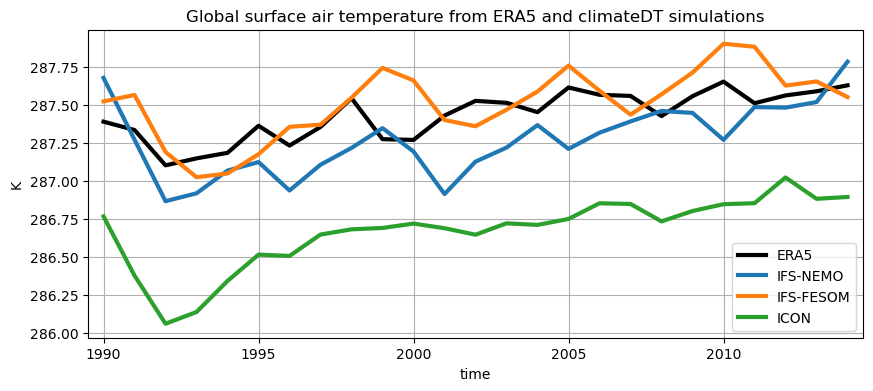

In [75]:
gsat_era5.groupby('time.year').mean().plot.line('k',lw=3,label='ERA5',figsize=(10,4))
gsat_nemo.groupby('time.year').mean().plot.line(lw=3,label='IFS-NEMO')
gsat_fesom.groupby('time.year').mean().plot.line(lw=3,label='IFS-FESOM')
gsat_icon.groupby('time.year').mean().plot.line(lw=3,label='ICON')
plt.legend()
plt.title('Global surface air temperature from ERA5 and climateDT simulations')
plt.ylabel('K')
plt.xlabel('time')
plt.grid(True)
plt.xlim(
    1989.5,
    2014.5
)

## Plot global maps

Text(0.5, 0.98, 'Mean 2m temperature (1990-2014)')

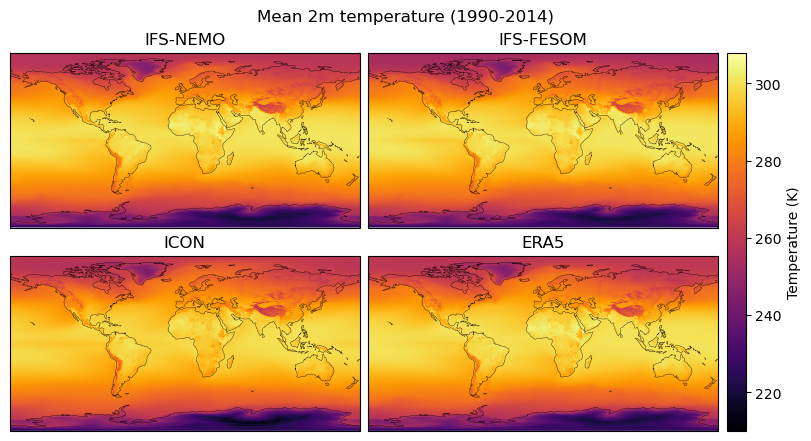

In [77]:
fig, axs = plt.subplots(2,2,sharex=True,sharey=True,constrained_layout=True,figsize=(8,4.3),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax = axs.flatten()

kwargs = dict(
    cmap='inferno',
    transform=ccrs.PlateCarree(),
    vmin=210,vmax=308,add_colorbar=False
)

i = 0
p = tas_nemo_mean.plot(ax=ax[i],**kwargs)
ax[i].set_title('IFS-NEMO')
i = 1
tas_fesom_mean.plot(ax=ax[i],**kwargs)
ax[i].set_title('IFS-FESOM')
i = 2
tas_icon_mean.plot(ax=ax[i],**kwargs)
ax[i].set_title('ICON')
i = 3
tas_era5_mean.plot(ax=ax[i],**kwargs)
ax[i].set_title('ERA5')

cbar = fig.colorbar(p,ax=ax,label='Temperature (K)',pad=0.0125)

for axi in ax:
    axi.coastlines(lw=0.25)
    # axi.gridlines(linestyle='--',lw=0.2)

fig.suptitle('Mean 2m temperature (1990-2014)')

Text(0.5, 0.98, '2m temperature bias relative to ERA5 (1990-2014)')

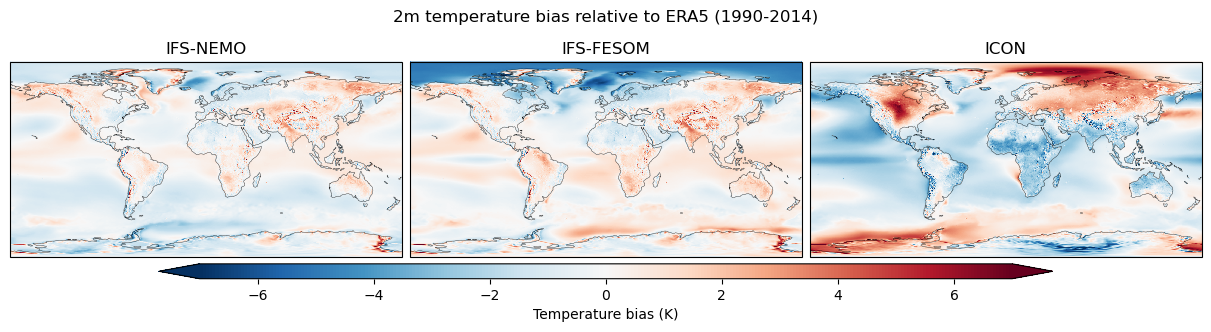

In [81]:
fig, axs = plt.subplots(1,3,sharex=True,sharey=True,constrained_layout=True,figsize=(12,3.2),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax = axs.flatten()

kwargs = dict(
    cmap='RdBu_r',
    transform=ccrs.PlateCarree(),
    vmax=7,add_colorbar=False
)

i = 0
p = (
    tas_nemo_mean
    - tas_era5_mean
).plot(ax=ax[i],**kwargs)
ax[i].set_title('IFS-NEMO')
i = 1
(
    tas_fesom_mean
    - tas_era5_mean
).plot(ax=ax[i],**kwargs)
ax[i].set_title('IFS-FESOM')
i = 2
(
    tas_icon_mean
    - tas_era5_mean
).plot(ax=ax[i],**kwargs)
ax[i].set_title('ICON')

cbar = fig.colorbar(p,ax=ax,label='Temperature bias (K)',extend='both',orientation='horizontal',pad=0.025,aspect=60,shrink=0.75)

for axi in ax:
    axi.coastlines(lw=0.25)
    # axi.gridlines(linestyle='--',lw=0.1)

fig.suptitle('2m temperature bias relative to ERA5 (1990-2014)')